In [1]:
# Magic iPython command to enable plotting
%matplotlib inline
import matplotlib.pyplot as plt
#plt.switch_backend('agg')

# Analysis libraries
import numpy as np
import matplotlib.pyplot as plt
import psana

import os
import sys

from psana import * 


In [2]:
def safe_get(det, evt):
    try:
        return det.get(evt)
    except Exception:
        return None
    
def mad(arr):
    """ Median Absolute Deviation: a "Robust" version of standard deviation.
        Indices variabililty of the sample.
        https://en.wikipedia.org/wiki/Median_absolute_deviation
    """
    #arr = np.ma.array(arr).compressed() # should be faster to not use masked arrays.
    med = np.nanmedian(arr)
    return med - 3.*np.nanmedian(np.abs(arr - med)), med + 3.*np.nanmedian(np.abs(arr - med))

In [8]:
# Specify experiment and run
experiment='cxil1015022'
#run=41
run = 42

# experiment = 'cxilv0418'
# run = 43

# Create a data source to grab data from
ds = psana.DataSource('exp=%s:run=%d' % (experiment , run))
spectrometer = psana.Detector('FEE-SPEC0')
nevent = 0
spec_array = np.array([])
for evt in ds.events():
    nevent+=1
    #print(nevent)
    if nevent == 10: break
    spectrometer_event = safe_get(spectrometer, evt)
    try:
        spec_com = spectrometer_event.com()
    except Exception:
        #print(nevent)
        continue
    spec_array = np.append(spec_array, spec_com)
    if nevent == 100: break
print('Processed',nevent,'events.')


Processed 10 events.


In [22]:
print(spectrometer_event.baseline())

0.0


In [24]:
help(spectrometer_event)

Help on BldDataSpectrometerV1 object:

class BldDataSpectrometerV1(Boost.Python.instance)
 |  Structure which contains image projections and fit parameters for spectrometers. 
 |  Changes from V0 include extending size of hproj, removal of vproj,
 |   and addition of fit parameters.
 |  
 |  Method resolution order:
 |      BldDataSpectrometerV1
 |      Boost.Python.instance
 |      builtins.object
 |  
 |  Static methods defined here:
 |  
 |  FWHM(...)
 |      FWHM( (BldDataSpectrometerV1)arg1) -> numpy.ndarray :
 |          Peak FWHM array, length given by nPeaks
 |               PV: TBD
 |  
 |  __init__(...)
 |      Raises an exception
 |      This class cannot be instantiated from Python
 |  
 |  __reduce__ = <unnamed Boost.Python function>(...)
 |  
 |  baseline(...)
 |      baseline( (BldDataSpectrometerV1)arg1) -> float :
 |          Baseline level for calculated values 
 |               PV: TBD
 |  
 |  com(...)
 |      com( (BldDataSpectrometerV1)arg1) -> float :
 |         

(968.22508146782, 1224.277859090258)


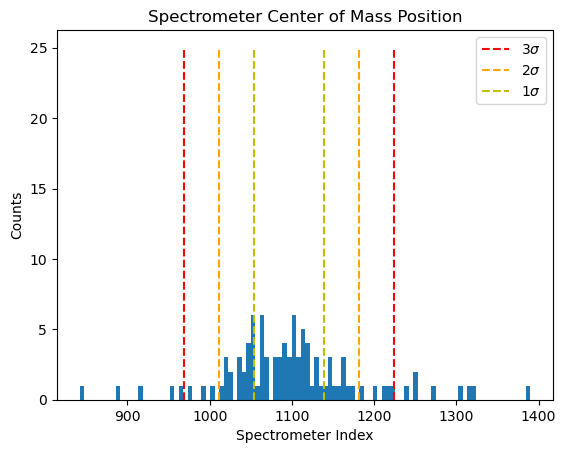

one sigma contains 55.556 percent of events
two sigma contains 61.616 percent of events
three sigma contains 83.838 percent of events


In [5]:
median = np.nanmedian(spec_array)
sigma = mad(spec_array)
print(sigma)
one_sigma = (sigma[1] - sigma[0])/6.

count_height = 25


plt.figure()
plt.hist(spec_array, bins = 100)
plt.vlines(sigma[0], 0, count_height, linestyle = '--', color = 'r', label = '3$\sigma$')
plt.vlines(sigma[1], 0, count_height, linestyle = '--', color = 'r')
plt.vlines(median - 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange', label = '2$\sigma$')
plt.vlines(median + 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange')
plt.vlines(median - one_sigma, 0, count_height, linestyle = '--', color = 'y', label = '1$\sigma$')
plt.vlines(median + one_sigma, 0, count_height, linestyle = '--', color = 'y')
plt.ylabel('Counts')
plt.xlabel('Spectrometer Index')
plt.title('Spectrometer Center of Mass Position')
plt.legend()
plt.show()

hist, bins = np.histogram(spec_array)
Bin_1 = np.digitize(median - one_sigma, bins)
Bin_2 = np.digitize(median + one_sigma, bins)
percent_1 = 100*np.sum(hist[Bin_1:Bin_2]/np.sum(hist))
Bin_3 = np.digitize(median - 2*one_sigma, bins)
Bin_4 = np.digitize(median + 2*one_sigma, bins)
percent_2 = 100*np.sum(hist[Bin_3:Bin_4]/np.sum(hist))
Bin_5 = np.digitize(median - 3*one_sigma, bins)
Bin_6 = np.digitize(median + 3*one_sigma, bins)
percent_3 = 100*np.sum(hist[Bin_5:Bin_6]/np.sum(hist))
print('one sigma contains %.3f percent of events' % percent_1)
print('two sigma contains %.3f percent of events' % percent_2)
print('three sigma contains %.3f percent of events' % percent_3)

In [6]:
pixel_array = np.array([1022.5, 974.5, 929, 719]) #Shift 4
energy_array = np.array([11.288, 11.283, 11.278, 11.254]) #Shift 4
pixel_array_day_2 = np.array([704, 1262])
energy_array_day_2 = np.array([11.1798, 11.2401])

def calibration(index_a, index_b):
    pixel_space = pixel_array[index_b] - pixel_array[index_a]
    energy_space = energy_array[index_b] - energy_array[index_a]
    energy_per_pixel = energy_space/pixel_space
    zero_energy_value = energy_array[index_a] - energy_per_pixel*pixel_array[index_a]
    return zero_energy_value, energy_per_pixel

def calibration_2(index_a, index_b):
    pixel_space = pixel_array_day_2[index_b] - pixel_array_day_2[index_a]
    energy_space = energy_array_day_2[index_b] - energy_array_day_2[index_a]
    energy_per_pixel = energy_space/pixel_space
    zero_energy_value = energy_array_day_2[index_a] - energy_per_pixel*pixel_array_day_2[index_a]
    return zero_energy_value, energy_per_pixel

ValueError: x and y must have same first dimension, but have shapes (99,) and (2048,)

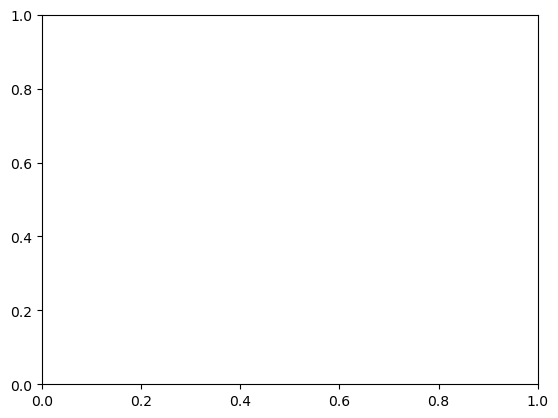

In [7]:
#zero_energy_value, energy_per_pixel = np.array(calibration(0,3))
zero_energy_value, energy_per_pixel = np.array(calibration_2(0,1))
#zero_energy_value_day_2 = calibration_day_2(0, energy_per_pixel)
spec_array_adjusted = zero_energy_value +spec_array*energy_per_pixel
plt.plot(spec_array_adjusted,spectrometer_event.hproj())

(11.208353355577975, 11.236023575095237)


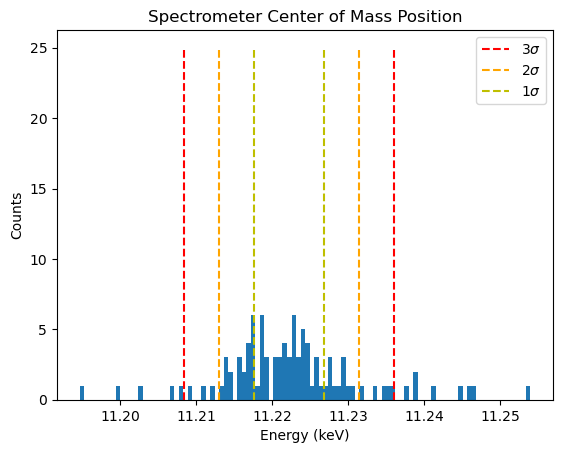

one sigma contains 55.556 percent of events
two sigma contains 61.616 percent of events
three sigma contains 83.838 percent of events


In [18]:
#zero_energy_value, energy_per_pixel = np.array(calibration(0,3))
zero_energy_value, energy_per_pixel = np.array(calibration_2(0,1))
#zero_energy_value_day_2 = calibration_day_2(0, energy_per_pixel)
spec_array_adjusted = zero_energy_value +spec_array*energy_per_pixel
#spec_array_adjusted = zero_energy_value_day_2 +spec_array*energy_per_pixel
median = np.nanmedian(spec_array_adjusted)
sigma = mad(spec_array_adjusted)
print(sigma)
one_sigma = (sigma[1] - sigma[0])/6.

plt.figure()
plt.hist(spec_array_adjusted, bins = 100)
plt.vlines(sigma[0], 0, count_height, linestyle = '--', color = 'r', label = '3$\sigma$')
plt.vlines(sigma[1], 0, count_height, linestyle = '--', color = 'r')
plt.vlines(median - 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange', label = '2$\sigma$')
plt.vlines(median + 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange')
plt.vlines(median - one_sigma, 0, count_height, linestyle = '--', color = 'y', label = '1$\sigma$')
plt.vlines(median + one_sigma, 0, count_height, linestyle = '--', color = 'y')
plt.ylabel('Counts')
plt.xlabel('Energy (keV)')
plt.title('Spectrometer Center of Mass Position')
plt.legend()
plt.show()

hist, bins = np.histogram(spec_array_adjusted)
Bin_1 = np.digitize(median - one_sigma, bins)
Bin_2 = np.digitize(median + one_sigma, bins)
percent_1 = 100*np.sum(hist[Bin_1:Bin_2]/np.sum(hist))
Bin_3 = np.digitize(median - 2*one_sigma, bins)
Bin_4 = np.digitize(median + 2*one_sigma, bins)
percent_2 = 100*np.sum(hist[Bin_3:Bin_4]/np.sum(hist))
Bin_5 = np.digitize(median - 3*one_sigma, bins)
Bin_6 = np.digitize(median + 3*one_sigma, bins)
percent_3 = 100*np.sum(hist[Bin_5:Bin_6]/np.sum(hist))
print('one sigma contains %.3f percent of events' % percent_1)
print('two sigma contains %.3f percent of events' % percent_2)
print('three sigma contains %.3f percent of events' % percent_3)

In [19]:
print(median)

11.222188465336606


## Checking Method Reliability

In [ ]:
# Specify experiment and run
experiment='cxil1015022'
run=23

# Create a data source to grab data from
ds = psana.DataSource('exp=%s:run=%d' % (experiment , run))
spectrometer = psana.Detector('FEE-SPEC0')
nevent = 0
spec_array = np.array([])
for evt in ds.events():
    nevent+=1
    spectrometer_event = safe_get(spectrometer, evt)
    try:
        spec_hproj = spectrometer_event.hproj()
        spec_com = spectrometer_event.com()
        spec_array = np.append(spec_array, spec_com)
    except Exception:
        continue
    # plt.figure()
    # plt.plot(spec_hproj)
    # plt.vlines(spec_com, 0, np.max(spec_hproj), linestyle = '--', color = 'black')
    # plt.show()
    if nevent==3000: break
print('Processed',nevent,'events.')


In [ ]:
# Specify experiment and run
experiment='cxil1015022'
run=44

# Create a data source to grab data from
ds = psana.DataSource('exp=%s:run=%d' % (experiment , run))
spectrometer = psana.Detector('FEE-SPEC0')
nevent = 0
spec_array_lingyu = np.array([])
x_array = np.arange(2048)
x_plotting = x_array*energy_per_pixel + zero_energy_value
for evt in ds.events():
    nevent+=1
    spectrometer_event = safe_get(spectrometer, evt)
    try:
        spec_hproj = spectrometer_event.hproj()
        spec_com = np.nansum(spec_hproj*x_array)/np.sum(spec_hproj)
        spec_array_lingyu = np.append(spec_array_lingyu, spec_com)
    except Exception:
        continue
    plt.figure()
    plt.plot(x_plotting, spec_hproj, label = 'X-ray spectrum')
    plt.vlines(spec_com*energy_per_pixel + zero_energy_value, 0, np.max(spec_hproj), linestyle = '--', color = 'black', label = 'COM position')
    plt.xlabel('Energy (keV)', fontsize = 14)
    plt.legend()
    plt.show()
    if nevent==10: break
print('Processed',nevent,'events.')



(11.260312683664118, 11.298245840755563)


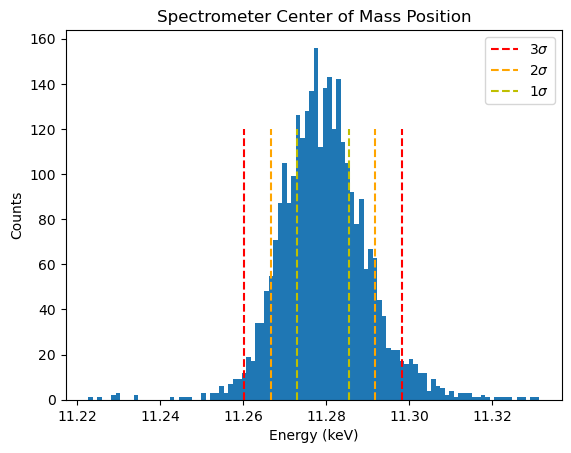

one sigma contains 40.000 percent of events
two sigma contains 54.733 percent of events
three sigma contains 88.433 percent of events


In [40]:
zero_energy_value, energy_per_pixel = np.array(calibration(0,3))
zero_energy_value_day_2 = calibration_day_2(0, energy_per_pixel)
#spec_array_adjusted = zero_energy_value +spec_array_lingyu*energy_per_pixel
spec_array_adjusted = zero_energy_value_day_2 +spec_array*energy_per_pixel
median = np.nanmedian(spec_array_adjusted)
sigma = mad(spec_array_adjusted)
print(sigma)
one_sigma = (sigma[1] - sigma[0])/6.

plt.figure()
plt.hist(spec_array_adjusted, bins = 100)
plt.vlines(sigma[0], 0, count_height, linestyle = '--', color = 'r', label = '3$\sigma$')
plt.vlines(sigma[1], 0, count_height, linestyle = '--', color = 'r')
plt.vlines(median - 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange', label = '2$\sigma$')
plt.vlines(median + 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange')
plt.vlines(median - one_sigma, 0, count_height, linestyle = '--', color = 'y', label = '1$\sigma$')
plt.vlines(median + one_sigma, 0, count_height, linestyle = '--', color = 'y')
plt.ylabel('Counts')
plt.xlabel('Energy (keV)')
plt.title('Spectrometer Center of Mass Position')
plt.legend()
plt.show()

hist, bins = np.histogram(spec_array_adjusted)
Bin_1 = np.digitize(median - one_sigma, bins)
Bin_2 = np.digitize(median + one_sigma, bins)
percent_1 = 100*np.sum(hist[Bin_1:Bin_2]/np.sum(hist))
Bin_3 = np.digitize(median - 2*one_sigma, bins)
Bin_4 = np.digitize(median + 2*one_sigma, bins)
percent_2 = 100*np.sum(hist[Bin_3:Bin_4]/np.sum(hist))
Bin_5 = np.digitize(median - 3*one_sigma, bins)
Bin_6 = np.digitize(median + 3*one_sigma, bins)
percent_3 = 100*np.sum(hist[Bin_5:Bin_6]/np.sum(hist))
print('one sigma contains %.3f percent of events' % percent_1)
print('two sigma contains %.3f percent of events' % percent_2)
print('three sigma contains %.3f percent of events' % percent_3)

In [41]:
print(median)

11.27927926220984


## Finding new calibration values

In [110]:
# Specify experiment and run
experiment='cxil1015022'
run=29

# Create a data source to grab data from
ds = psana.DataSource('exp=%s:run=%d' % (experiment , run))
spectrometer = psana.Detector('FEE-SPEC0')
nevent = 0
spec_array = np.array([])
for evt in ds.events():
    nevent+=1
    spectrometer_event = safe_get(spectrometer, evt)
    try:
        spec_hproj = spectrometer_event.hproj()
        spec_array = np.append(spec_array, spec_hproj)
    except Exception:
        continue
    if nevent==1000: break
print('Processed',nevent,'events.')




Processed 1000 events.


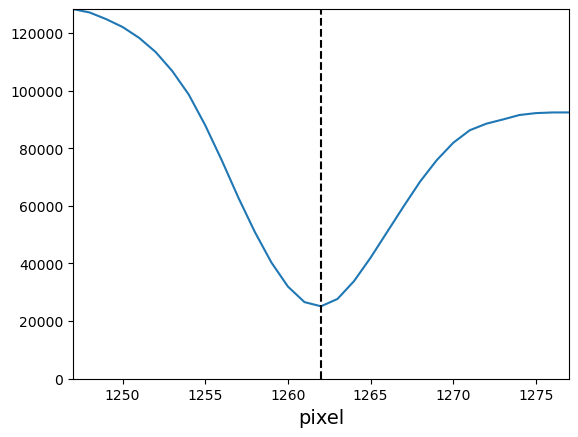

11.2401 keV falls at pixel 1262.0


In [119]:
spec_array = np.reshape(spec_array, (nevent, 2048))
spec_average = np.nanmean(spec_array, axis = 0)

energy_value = 11.2401
spec_guess = 1262
spec_space = 15

plt.figure()
plt.plot(spec_average)
plt.vlines(spec_guess, 0, np.max(spec_hproj), linestyle = '--', color = 'black')
plt.xlim(spec_guess - spec_space, spec_guess + spec_space)
plt.ylim(0, np.max(spec_average[spec_guess - spec_space:spec_guess + spec_space]))
plt.xlabel('pixel', fontsize = 14)
plt.show()
print('%.4f keV falls at pixel %.1f' %(energy_value, spec_guess))

In [83]:
def calibration_day_2(index_a, energy_per_pixel):
    zero_energy_value_day_2 = energy_array_day_2[index_a] - energy_per_pixel*pixel_array_day_2[index_a]
    return zero_energy_value_day_2

(11.179410206234408, 11.218193462958062)


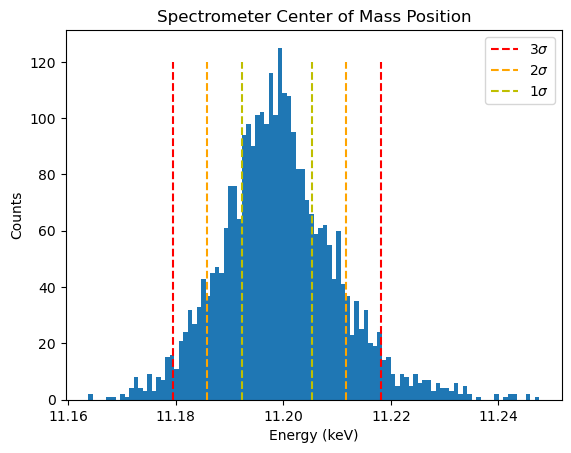

one sigma contains 31.833 percent of events
two sigma contains 76.367 percent of events
three sigma contains 93.900 percent of events


In [93]:
zero_energy_value, energy_per_pixel = np.array(calibration(0,3))
zero_energy_value_day_2 = calibration_day_2(0, energy_per_pixel)
spec_array_adjusted = zero_energy_value_day_2 +spec_array*energy_per_pixel
median = np.nanmedian(spec_array_adjusted)
sigma = mad(spec_array_adjusted)
print(sigma)
one_sigma = (sigma[1] - sigma[0])/6.

plt.figure()
plt.hist(spec_array_adjusted, bins = 100)
plt.vlines(sigma[0], 0, count_height, linestyle = '--', color = 'r', label = '3$\sigma$')
plt.vlines(sigma[1], 0, count_height, linestyle = '--', color = 'r')
plt.vlines(median - 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange', label = '2$\sigma$')
plt.vlines(median + 2*one_sigma, 0, count_height, linestyle = '--', color = 'orange')
plt.vlines(median - one_sigma, 0, count_height, linestyle = '--', color = 'y', label = '1$\sigma$')
plt.vlines(median + one_sigma, 0, count_height, linestyle = '--', color = 'y')
plt.ylabel('Counts')
plt.xlabel('Energy (keV)')
plt.title('Spectrometer Center of Mass Position')
plt.legend()
plt.show()

hist, bins = np.histogram(spec_array_adjusted)
Bin_1 = np.digitize(median - one_sigma, bins)
Bin_2 = np.digitize(median + one_sigma, bins)
percent_1 = 100*np.sum(hist[Bin_1:Bin_2]/np.sum(hist))
Bin_3 = np.digitize(median - 2*one_sigma, bins)
Bin_4 = np.digitize(median + 2*one_sigma, bins)
percent_2 = 100*np.sum(hist[Bin_3:Bin_4]/np.sum(hist))
Bin_5 = np.digitize(median - 3*one_sigma, bins)
Bin_6 = np.digitize(median + 3*one_sigma, bins)
percent_3 = 100*np.sum(hist[Bin_5:Bin_6]/np.sum(hist))
print('one sigma contains %.3f percent of events' % percent_1)
print('two sigma contains %.3f percent of events' % percent_2)
print('three sigma contains %.3f percent of events' % percent_3)